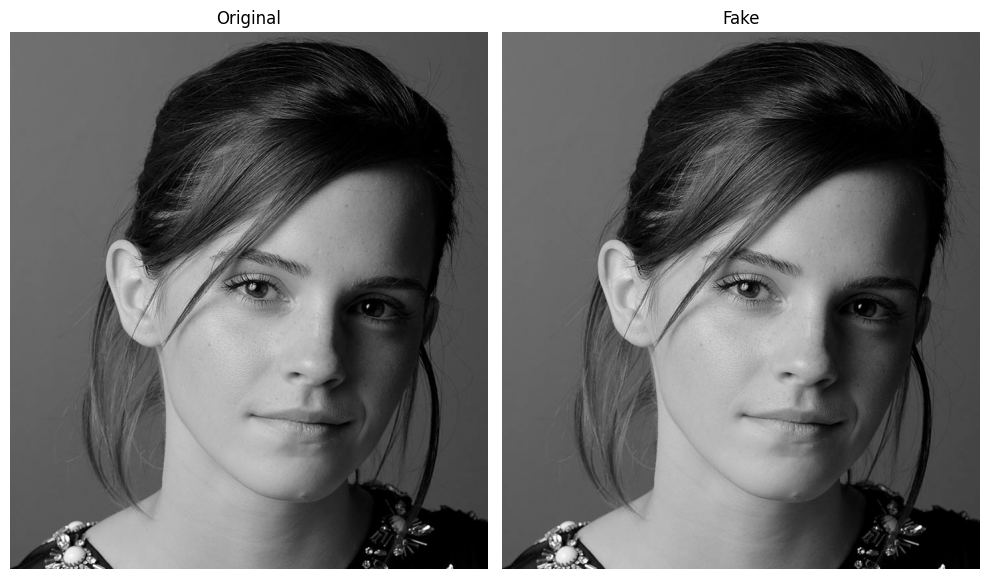

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
t = np.arange(256, dtype= np.uint8)
g = t[f]

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(f, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title("Fake")
plt.imshow(g, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

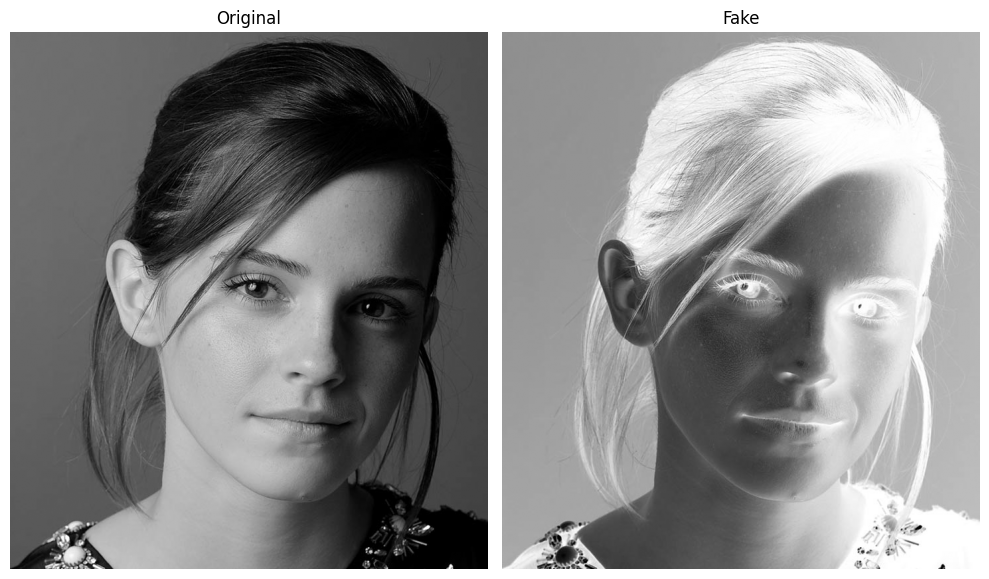

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
t = 255 - np.arange(256, dtype= np.uint8)
g = t[f]

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(f, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title("Fake")
plt.imshow(g, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

256


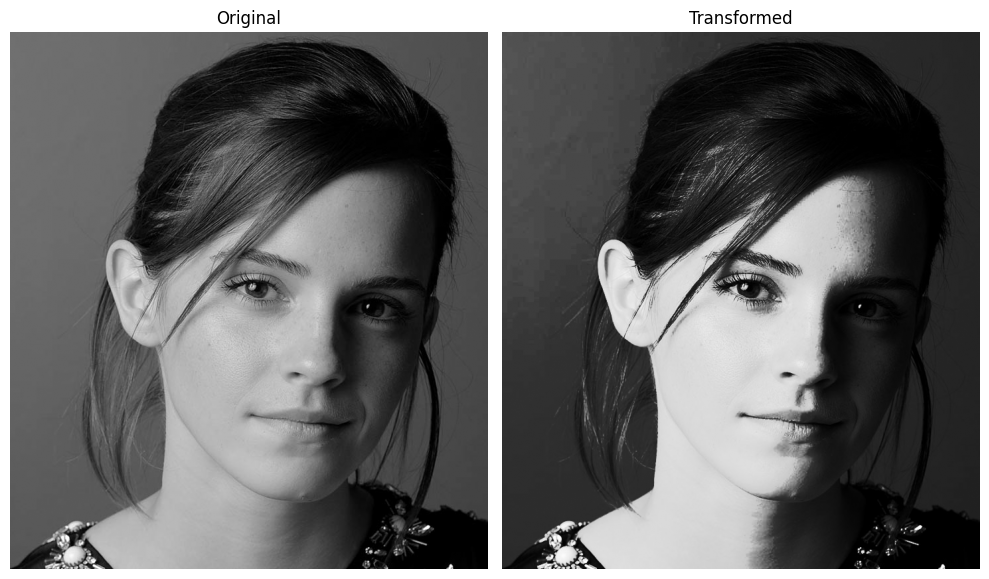

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

c = np.array([(100,50), (150,200)])

t1 = np.linspace(0, c[0,1], c[0,0] +1).astype('uint8')
t2 = np.linspace(c[0,1] + 1, c[1,1], c[0,0] - c[0,1]).astype('uint8')
t3 = np.linspace(c[1,1] +1, 255, 255 - c[1,0]).astype('uint8')

transform = np.concatenate((t1, t2), axis= 0).astype('uint8')
transform = np.concatenate((transform, t3), axis = 0).astype('uint8')
print(len(transform))

original = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
transformed = cv.LUT(original, transform)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 2, 2)
plt.title("Transformed")
plt.imshow(transformed, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

Transform at key points:
Input 0 -> Output 0 (should be 0)
Input 50 -> Output 100 (should be 100)
Input 150 -> Output 150 (should be 150)
Input 255 -> Output 255 (should be 255)


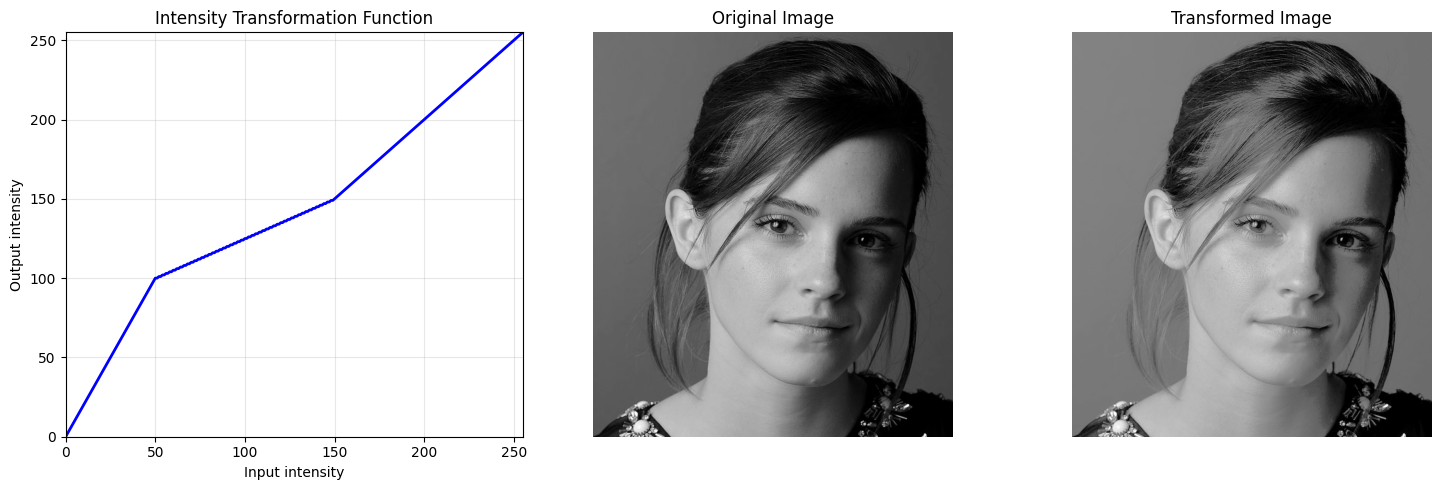

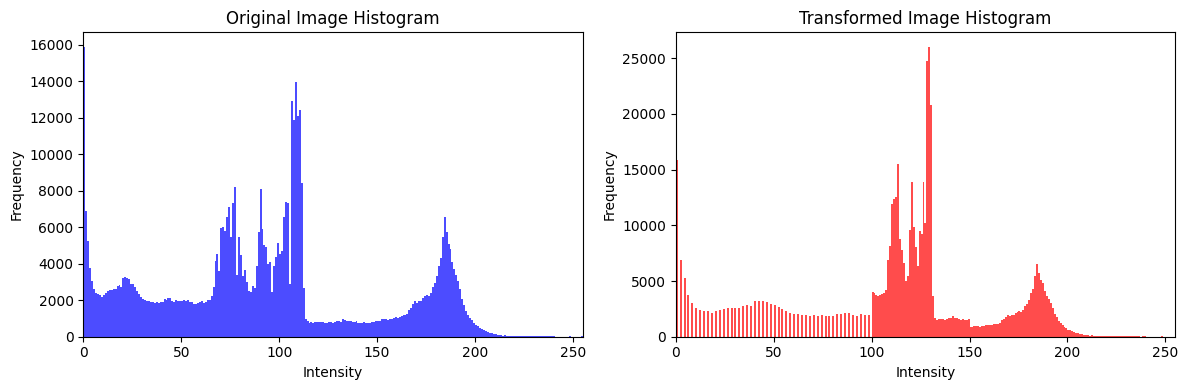

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Create the lookup table for the intensity transformation
transform = np.zeros(256, dtype='uint8')

# Segment 1: Input 0-50 maps to Output 0-100 (slope = 2)
for i in range(51):
    transform[i] = int(2 * i)

# Segment 2: Input 50-150 maps to Output 100-150 (slope = 0.5)
for i in range(51, 151):
    transform[i] = int(100 + 0.5 * (i - 50))

# Segment 3: Input 150-255 maps to Output 150-255 (slope = 1)
for i in range(151, 256):
    transform[i] = int(150 + (i - 150))

# Verify the transformation at key points
print(f"Transform at key points:")
print(f"Input 0 -> Output {transform[0]} (should be 0)")
print(f"Input 50 -> Output {transform[50]} (should be 100)")
print(f"Input 150 -> Output {transform[150]} (should be 150)")
print(f"Input 255 -> Output {transform[255]} (should be 255)")

# Load and transform the image
original = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
transformed = cv.LUT(original, transform)

# Plot the transformation function
plt.figure(figsize=(15, 5))

# Plot 1: Transformation function
plt.subplot(1, 3, 1)
plt.plot(range(256), transform, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity Transformation Function')
plt.xlim(0, 255)
plt.ylim(0, 255)

# Plot 2: Original image
plt.subplot(1, 3, 2)
plt.title("Original Image")
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

# Plot 3: Transformed image
plt.subplot(1, 3, 3)
plt.title("Transformed Image")
plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Display histogram comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(original.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title('Original Image Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.xlim(0, 255)

plt.subplot(1, 2, 2)
plt.hist(transformed.ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
plt.title('Transformed Image Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

## Gamma Correction ##

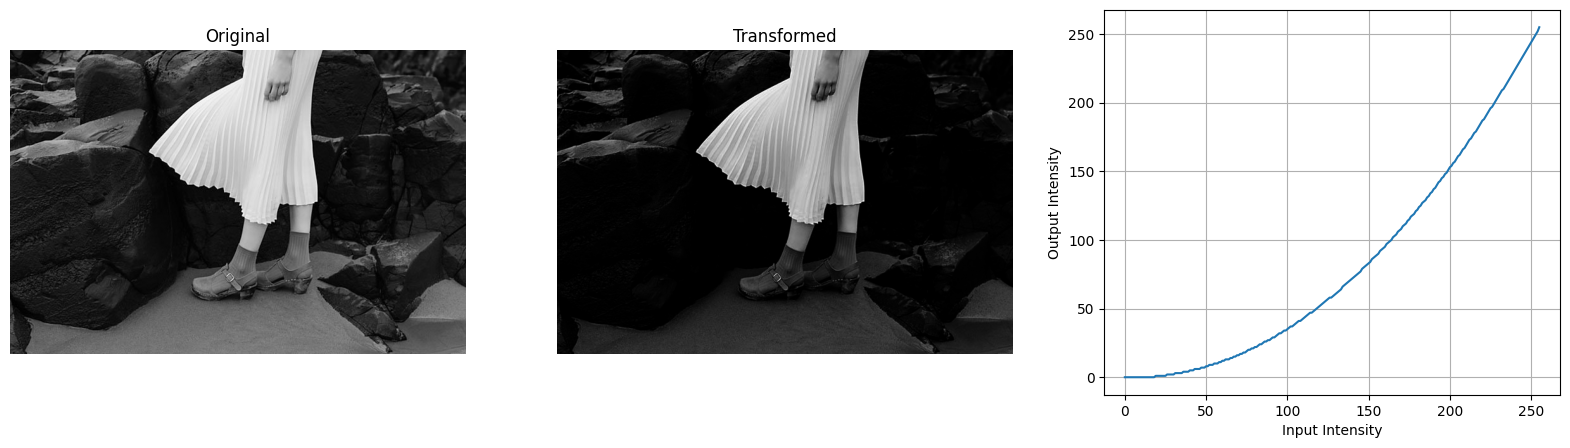

<Figure size 640x480 with 0 Axes>

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gamma = 2.1
original = cv.imread('images/highlights_and_shadows.jpg', cv.IMREAD_GRAYSCALE)
transform = np.array([(i/255)**(gamma)*255 for i in np.arange(0,256)]).astype('uint8')
transformed = cv.LUT(original, transform)

plt.figure(figsize=(20,5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')


plt.subplot(1, 3, 2)
plt.title("Transformed")
plt.imshow(transformed, cmap= 'gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(np.arange(256), transform)
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.grid(True)
plt.show()


plt.tight_layout()
plt.show()

### Histogram Equalization ###

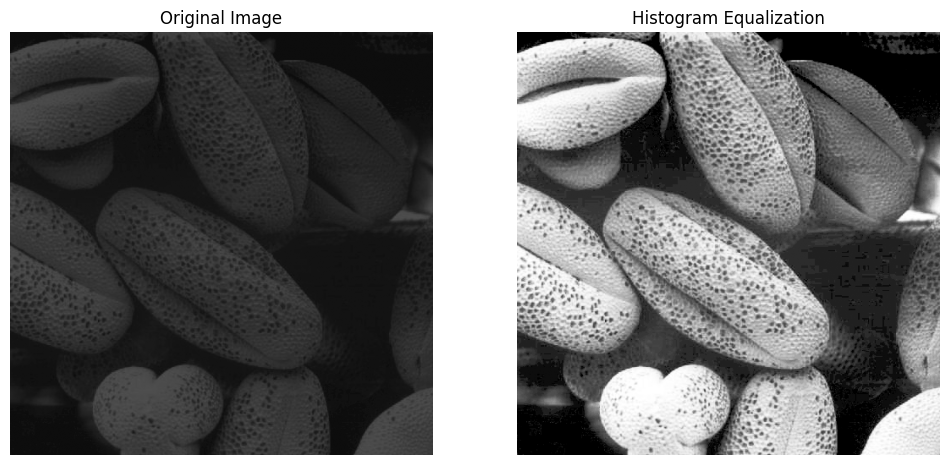

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)

# Check if image loaded properly
if img is None:
    raise FileNotFoundError("Image not found. Check the path.")

# Apply histogram equalization using OpenCV function
img_eq = cv.equalizeHist(img)

# Plot original and equalized images side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

ax[0].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Histogram Equalization')
ax[1].axis('off')

plt.show()


[77 77 45 ... 72 65 71]


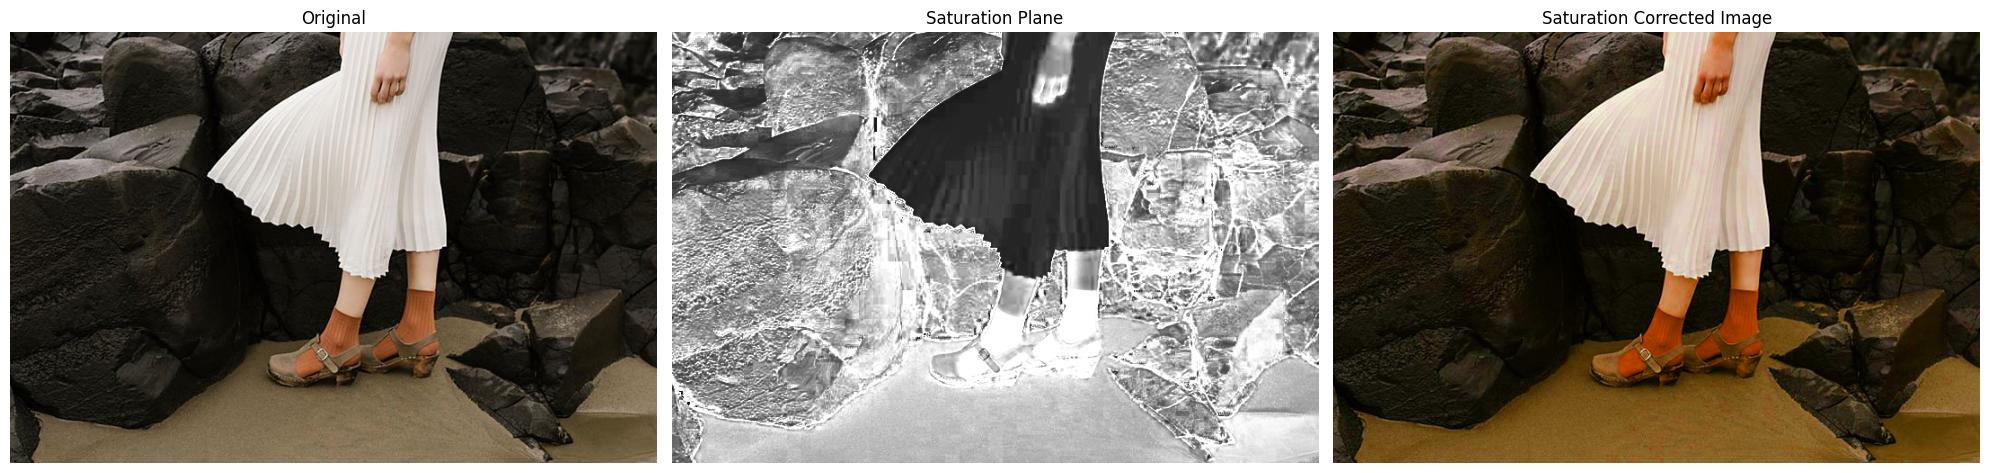

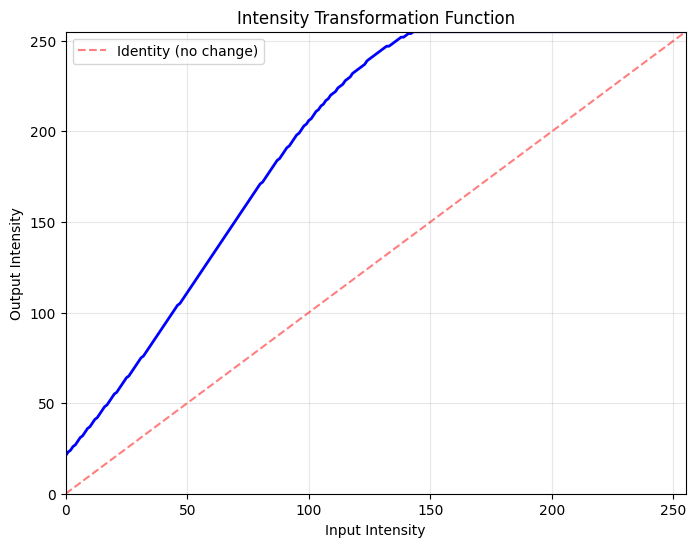

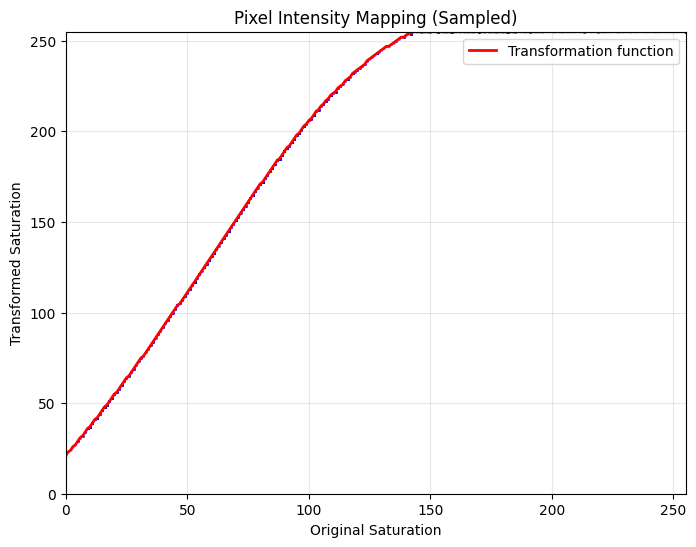

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('images/highlights_and_shadows.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
h, s, v = cv.split(hsv)

a = 0.9
sigma = 70
transform = np.array([
    min(i + a * 128 * np.exp(-((i - 128)**2 / (2 * sigma**2))), 255)
    for i in range(256)
]).astype('uint8')

s_transformed = cv.LUT(s, transform)
transformed = cv.merge([h, s_transformed, v])
corrected_image = cv.cvtColor(transformed, cv.COLOR_HSV2RGB)

s_flattened = s.flatten()
s_transformed_flattened = s_transformed.flatten()
print(s_flattened)

plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saturation Plane")
plt.imshow(s_transformed, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Saturation Corrected Image")
plt.imshow(corrected_image, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.tight_layout()
plt.show()

# CORRECTED INTENSITY TRANSFORMATION GRAPH
plt.figure(figsize=(8, 6))
# Plot the actual transformation function using the lookup table
input_values = np.arange(256)
output_values = transform
plt.plot(input_values, output_values, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Intensity Transformation Function')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
# Add diagonal reference line (no transformation)
plt.plot([0, 255], [0, 255], 'r--', alpha=0.5, label='Identity (no change)')
plt.legend()
plt.show()

# Optional: Show the scatter plot of actual pixel mappings
plt.figure(figsize=(8, 6))
# Sample pixels for visualization (plotting all pixels would be too dense)
sample_indices = np.random.choice(len(s_flattened), min(5000, len(s_flattened)), replace=False)
plt.scatter(s_flattened[sample_indices], s_transformed_flattened[sample_indices], 
            alpha=0.1, s=1, c='blue')
plt.plot(input_values, output_values, 'r-', linewidth=2, label='Transformation function')
plt.grid(True, alpha=0.3)
plt.title('Pixel Intensity Mapping (Sampled)')
plt.xlabel('Original Saturation')
plt.ylabel('Transformed Saturation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.legend()
plt.show()